In [2]:
!pip install torch torchvision torchaudio
!pip install torchdiffeq
!pip install numpy matplotlib

In [3]:
import torch
import torch.nn as nn
from torchdiffeq import odeint

class ODEFxn(nn.Module):
    def __init__(self):
        super(ODEFxn, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 50),
            nn.Tanh(),
            nn.Linear(50, 2)
        )

    def forward(self, t, x):
        return self.net(x)

x0 = torch.tensor([[1.0, 0.0]])
t = torch.linspace(0., 10., 100)
func = ODEFxn()
pred_x = odeint(func, x0, t)

print("Shape of predicted states:", pred_x.shape)

Shape of predicted states: torch.Size([100, 1, 2])


In [4]:
import torch.optim as optim

class ODEFxn(nn.Module):
    def __init__(self):
        super(ODEFxn, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 50),
            nn.Tanh(),
            nn.Linear(50, 2)
        )

    def forward(self, t, x):
        return self.net(x)

t = torch.linspace(0., 5., 100) 
x0 = torch.tensor([[1.0, 0.0]]) 

true_x = torch.stack([torch.cos(t), -torch.sin(t)], dim=1).unsqueeze(1)

func = ODEFxn()
optimizer = optim.Adam(func.parameters(), lr=0.01)
loss_fn = nn.MSELoss() 

print("Initiating Training Process...\n")

for epoch in range(150):
    optimizer.zero_grad()
    pred_x = odeint(func, x0, t)
    loss = loss_fn(pred_x, true_x)
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Continuous Loss: {loss.item():.4f}")

print("\nTraining Complete! The Neural ODE has learned the system's dynamics.")

Initiating Training Process...

Epoch 000 | Continuous Loss: 2.1312
Epoch 020 | Continuous Loss: 0.1844
Epoch 040 | Continuous Loss: 0.0946
Epoch 060 | Continuous Loss: 0.0496
Epoch 080 | Continuous Loss: 0.0159
Epoch 100 | Continuous Loss: 0.0019
Epoch 120 | Continuous Loss: 0.0005
Epoch 140 | Continuous Loss: 0.0003

Training Complete! The Neural ODE has learned the system's dynamics.


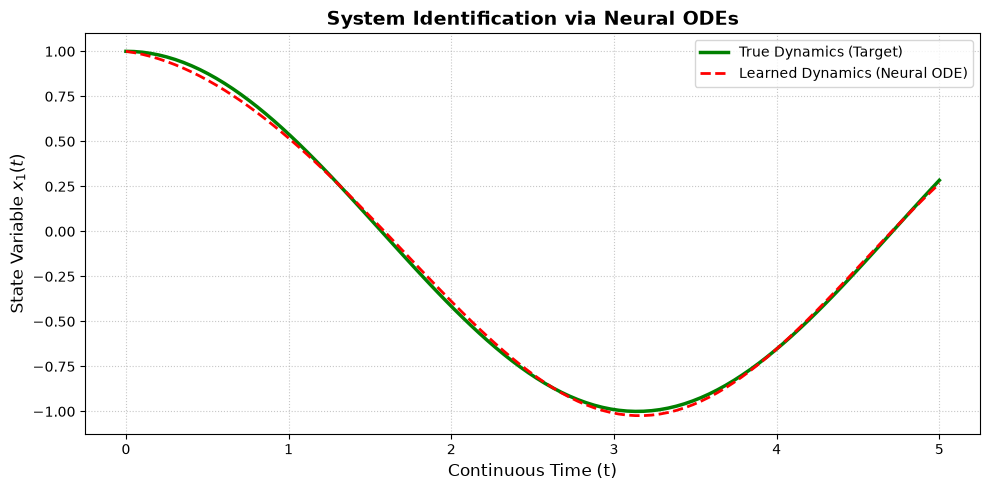

In [5]:
import matplotlib.pyplot as plt
import numpy as np

t_np = t.detach().numpy()
true_x_np = true_x.detach().numpy().squeeze()
pred_x_np = pred_x.detach().numpy().squeeze()

plt.figure(figsize=(10, 5))

plt.plot(t_np, true_x_np[:, 0], 'g-', label='True Dynamics (Target)', linewidth=2.5)
plt.plot(t_np, pred_x_np[:, 0], 'r--', label='Learned Dynamics (Neural ODE)', linewidth=2)

plt.title("System Identification via Neural ODEs", fontsize=14, fontweight='bold')
plt.xlabel("Continuous Time (t)", fontsize=12)
plt.ylabel("State Variable $x_1(t)$", fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [6]:
!pip install scanpy

import scanpy as sc
import numpy as np

sc.settings.verbosity = 3
sc.logging.print_header()

print("\n--- 1. Data Ingestion ---")
adata = sc.datasets.pbmc3k()
print(f"Raw Data Shape: {adata.shape}")

print("\n--- 2. Signal Filtering (Quality Control) ---")
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

print("\n--- 3. Normalization ---")
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

print("\n--- 4. Dimensionality Reduction (Dominant States) ---")
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5, n_top_genes=2000)

adata = adata[:, adata.var.highly_variable]

print(f"\nFinal State-Space Dimensions: Cells={adata.n_obs}, Genes (State Variables)={adata.n_vars}")


--- 1. Data Ingestion ---
Raw Data Shape: (2700, 32738)

--- 2. Signal Filtering (Quality Control) ---
filtered out 19024 genes that are detected in less than 3 cells

--- 3. Normalization ---
normalizing counts per cell
    finished (0:00:02)

--- 4. Dimensionality Reduction (Dominant States) ---
extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)

Final State-Space Dimensions: Cells=2700, Genes (State Variables)=2000


--- 1. Subspace Projection (PCA) ---
computing PCA
    with n_comps=50
    finished (0:00:00)

--- 2. Constructing the State Manifold Graph (KNN) ---
computing neighbors
    using 'X_pca' with n_pcs = 30


c:\Users\AmiraliOliaeimehr\AppData\Local\Programs\Python\Python313\Lib\site-packages\scanpy\preprocessing\_pca\__init__.py:357: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca
c:\Users\AmiraliOliaeimehr\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:11)

--- 3. Low-Dimensional Manifold Embedding (UMAP) ---
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:02)

--- 4. Random Walk Diffusion Analysis ---
computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.9994543  0.99652433 0.98430496 0.9807514  0.96912587
     0.9462159  0.9398871  0.90399504 0.88058674 0.864294   0.84013134
     0.8314648  0.81855166 0.77378726]
    finished: added
    'X_diffmap', diffmap coordinates (adata.obsm)
    'diffmap_evals', eigenvalues of transition matrix (adata.uns) (0:00:00)

--- 5. Determining the Origin & Computing Diffusion Pseudotime ---
computing Diffusion Pseudotime using n_dcs=10
    finished: added
    'dpt

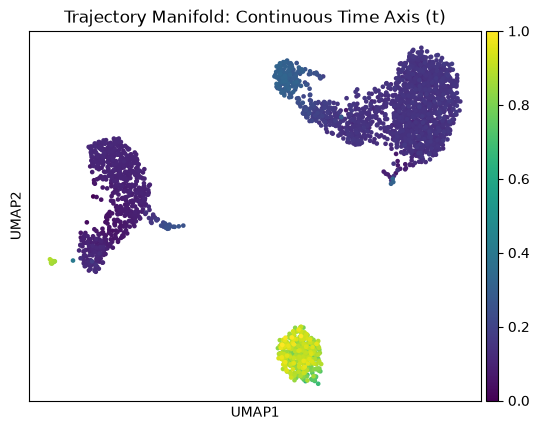

In [7]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

print("--- 1. Subspace Projection (PCA) ---")
sc.tl.pca(adata, svd_solver='arpack', n_comps=50)

print("\n--- 2. Constructing the State Manifold Graph (KNN) ---")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)

print("\n--- 3. Low-Dimensional Manifold Embedding (UMAP) ---")
sc.tl.umap(adata)

print("\n--- 4. Random Walk Diffusion Analysis ---")
sc.tl.diffmap(adata)

print("\n--- 5. Determining the Origin & Computing Diffusion Pseudotime ---")
root_cell_index = np.argmin(adata.obsm['X_diffmap'][:, 1])
adata.uns['iroot'] = root_cell_index

sc.tl.dpt(adata)

print(f"Root cell index selected at: {root_cell_index}")
print("Pseudotime computation completed successfully.")

print("\n--- 6. Visualizing the Continuous Trajectory ---")
sc.pl.umap(
    adata, 
    color=['dpt_pseudotime'], 
    color_map='viridis', 
    title='Trajectory Manifold: Continuous Time Axis (t)',
    show=True
)

In [8]:
!pip install leidenalg igraph

--- 1. Topological Clustering (Leiden Algorithm) ---
running Leiden clustering
    finished: found 8 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


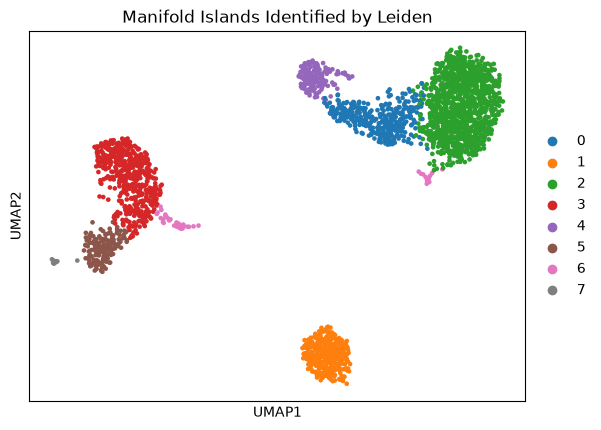


--- 2. Manifold Surgery (Isolating the Continuous Trajectory) ---
Original State-Space Samples: 2700
Surgically Isolated Continuous Samples: 713
computing Diffusion Pseudotime using n_dcs=10
    finished: added
    'dpt_pseudotime', the pseudotime (adata.obs) (0:00:00)

The continuous state-space is now mathematically valid for Neural ODEs.


In [9]:
import scanpy as sc
import numpy as np

print("--- 1. Topological Clustering (Leiden Algorithm) ---")
sc.tl.leiden(adata, resolution=0.5, flavor='igraph')

sc.pl.umap(adata, color='leiden', title='Manifold Islands Identified by Leiden', show=True)

print("\n--- 2. Manifold Surgery (Isolating the Continuous Trajectory) ---")
continuous_adata = adata[adata.obs['leiden'].isin(['0', '1'])].copy()

print(f"Original State-Space Samples: {adata.n_obs}")
print(f"Surgically Isolated Continuous Samples: {continuous_adata.n_obs}")

root_idx = np.argmin(continuous_adata.obsm['X_diffmap'][:, 1])
continuous_adata.uns['iroot'] = root_idx
sc.tl.dpt(continuous_adata)

print("\nThe continuous state-space is now mathematically valid for Neural ODEs.")

--- Manifold Surgery: Isolating the True Continuous Trajectory ---
Original State-Space Samples: 2700
Surgically Isolated Continuous Samples: 1642

--- Resetting and Computing the Continuous Time Axis (t) ---
computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.9852671  0.9419208  0.88066304 0.8613789  0.8320868
     0.76923084 0.7630765  0.7483994  0.74187577 0.726006   0.7073537
     0.70008355 0.69343984 0.6851718 ]
    finished: added
    'X_diffmap', diffmap coordinates (adata.obsm)
    'diffmap_evals', eigenvalues of transition matrix (adata.uns) (0:00:00)
computing Diffusion Pseudotime using n_dcs=10
    finished: added
    'dpt_pseudotime', the pseudotime (adata.obs) (0:00:00)
Success! The time axis (t) is now perfectly calibrated for this specific island.


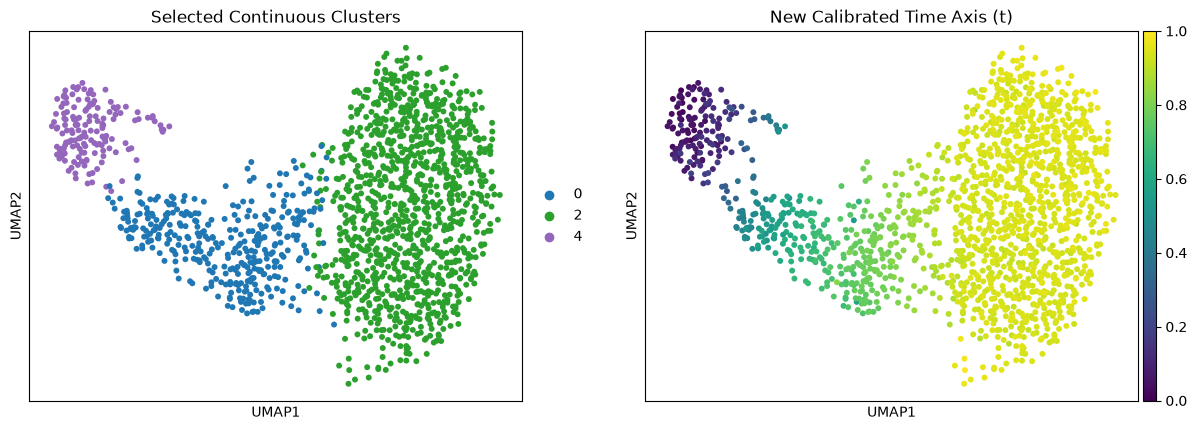

In [10]:
import numpy as np

print("--- Manifold Surgery: Isolating the True Continuous Trajectory ---")
continuous_adata = adata[adata.obs['leiden'].isin(['0', '2', '4'])].copy()

print(f"Original State-Space Samples: {adata.n_obs}")
print(f"Surgically Isolated Continuous Samples: {continuous_adata.n_obs}")

print("\n--- Resetting and Computing the Continuous Time Axis (t) ---")
sc.tl.diffmap(continuous_adata)

root_idx = np.argmin(continuous_adata.obsm['X_diffmap'][:, 1])
continuous_adata.uns['iroot'] = root_idx

sc.tl.dpt(continuous_adata)

print("Success! The time axis (t) is now perfectly calibrated for this specific island.")

sc.pl.umap(
    continuous_adata, 
    color=['leiden', 'dpt_pseudotime'], 
    color_map='viridis', 
    title=['Selected Continuous Clusters', 'New Calibrated Time Axis (t)'],
    show=True
)

In [11]:
import torch
import pandas as pd
from scipy.sparse import issparse

print("--- 1. Extracting and Sorting the State-Space ---")
pseudotime = continuous_adata.obs['dpt_pseudotime'].values
sorted_indices = np.argsort(pseudotime)

sorted_time = pseudotime[sorted_indices]
if issparse(continuous_adata.X):
    sorted_X = continuous_adata.X[sorted_indices].toarray()
else:
    sorted_X = continuous_adata.X[sorted_indices]

print("\n--- 2. Trajectory Smoothing (Binning) ---")
n_steps = 50
bins = np.linspace(0, 1, n_steps + 1)
bin_indices = np.digitize(sorted_time, bins) - 1

smoothed_x = []
smoothed_t = []

for i in range(n_steps):
    cells_in_bin = sorted_X[bin_indices == i]
    times_in_bin = sorted_time[bin_indices == i]
    
    if len(cells_in_bin) > 0:
        smoothed_x.append(np.mean(cells_in_bin, axis=0))
        smoothed_t.append(np.mean(times_in_bin))

smoothed_x = np.array(smoothed_x)
smoothed_t = np.array(smoothed_t)

print(f"Original noisy steps: {len(sorted_time)} -> Smoothed ideal steps: {len(smoothed_t)}")

print("\n--- 3. Converting to PyTorch Tensors ---")
tensor_x = torch.tensor(smoothed_x, dtype=torch.float32).unsqueeze(1) 
tensor_t = torch.tensor(smoothed_t, dtype=torch.float32)

print(f"Final Input Tensor Shape: {tensor_x.shape}")
print(f"Final Time Tensor Shape: {tensor_t.shape}")
print("\nSuccess! The data is mathematically structured and ready for PyTorch.")

--- 1. Extracting and Sorting the State-Space ---

--- 2. Trajectory Smoothing (Binning) ---
Original noisy steps: 1642 -> Smoothed ideal steps: 50

--- 3. Converting to PyTorch Tensors ---
Final Input Tensor Shape: torch.Size([50, 1, 2000])
Final Time Tensor Shape: torch.Size([50])

Success! The data is mathematically structured and ready for PyTorch.


In [12]:
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint
import time

print("--- 1. Upgrading the Neural ODE Architecture ---")
class BiologicalODEFxn(nn.Module):
    def __init__(self, state_dim=2000):
        super(BiologicalODEFxn, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ELU(), 
            nn.Linear(256, 256),
            nn.ELU(),
            nn.Linear(256, state_dim)
        )

    def forward(self, t, x):
        return self.net(x)

func = BiologicalODEFxn(state_dim=2000)

print("--- 2. Setting up the Optimizer and Initial Conditions ---")
optimizer = optim.Adam(func.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

x0 = tensor_x[0] 

print("--- 3. Initiating the Continuous Training Loop ---\n")
epochs = 100
start_time = time.time()

for epoch in range(1, epochs + 1):
    optimizer.zero_grad()
    
    pred_x = odeint(func, x0, tensor_t, method='rk4')
    
    loss = loss_fn(pred_x, tensor_x)
    
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Continuous Loss (MSE): {loss.item():.4f}")

end_time = time.time()
print(f"\nTraining completed in {end_time - start_time:.2f} seconds!")
print("The Neural ODE has successfully mapped the biological trajectory.")

--- 1. Upgrading the Neural ODE Architecture ---
--- 2. Setting up the Optimizer and Initial Conditions ---
--- 3. Initiating the Continuous Training Loop ---



Epoch 010 | Continuous Loss (MSE): 0.0597
Epoch 020 | Continuous Loss (MSE): 0.0504
Epoch 030 | Continuous Loss (MSE): 0.0466
Epoch 040 | Continuous Loss (MSE): 0.0438
Epoch 050 | Continuous Loss (MSE): 0.0423
Epoch 060 | Continuous Loss (MSE): 0.0415
Epoch 070 | Continuous Loss (MSE): 0.0409
Epoch 080 | Continuous Loss (MSE): 0.0409
Epoch 090 | Continuous Loss (MSE): 0.0406
Epoch 100 | Continuous Loss (MSE): 0.0401

Training completed in 8.65 seconds!
The Neural ODE has successfully mapped the biological trajectory.


--- Visualizing System Tracking Performance ---


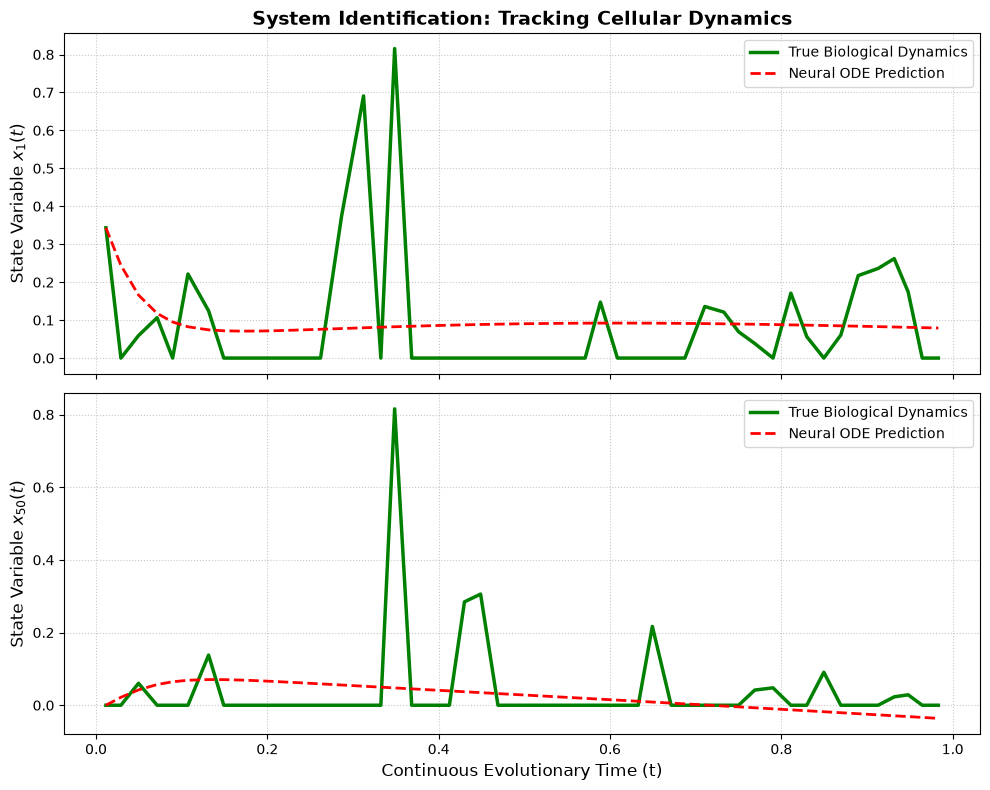

In [13]:
import matplotlib.pyplot as plt
import numpy as np

print("--- Visualizing System Tracking Performance ---")

t_np = tensor_t.detach().numpy()
true_x_np = tensor_x.detach().numpy().squeeze()
pred_x_np = pred_x.detach().numpy().squeeze()

state_1_idx = 0
state_2_idx = 50

fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axs[0].plot(t_np, true_x_np[:, state_1_idx], 'g-', label='True Biological Dynamics', linewidth=2.5)
axs[0].plot(t_np, pred_x_np[:, state_1_idx], 'r--', label='Neural ODE Prediction', linewidth=2)
axs[0].set_ylabel("State Variable $x_1(t)$", fontsize=12)
axs[0].set_title("System Identification: Tracking Cellular Dynamics", fontsize=14, fontweight='bold')
axs[0].legend()
axs[0].grid(True, linestyle=':', alpha=0.7)

axs[1].plot(t_np, true_x_np[:, state_2_idx], 'g-', label='True Biological Dynamics', linewidth=2.5)
axs[1].plot(t_np, pred_x_np[:, state_2_idx], 'r--', label='Neural ODE Prediction', linewidth=2)
axs[1].set_xlabel("Continuous Evolutionary Time (t)", fontsize=12)
axs[1].set_ylabel("State Variable $x_{50}(t)$", fontsize=12)
axs[1].legend()
axs[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [14]:
import torch
import torch.nn as nn
from torchdiffeq import odeint

print("--- Constructing Latent Neural ODE Architecture ---")

class Encoder(nn.Module):
    def __init__(self, input_dim=2000, latent_dim=20):
        super(Encoder, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ELU(),
            nn.Linear(256, latent_dim)
        )
    def forward(self, x):
        return self.net(x)

class LatentODEFxn(nn.Module):
    def __init__(self, latent_dim=20):
        super(LatentODEFxn, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ELU(),
            nn.Linear(64, latent_dim)
        )
    def forward(self, t, z):
        return self.net(z)

class Decoder(nn.Module):
    def __init__(self, latent_dim=20, output_dim=2000):
        super(Decoder, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ELU(),
            nn.Linear(256, output_dim)
        )
    def forward(self, z):
        return self.net(z)

class LatentODEModel(nn.Module):
    def __init__(self, input_dim=2000, latent_dim=20):
        super(LatentODEModel, self).__init__()
        self.encoder = Encoder(input_dim, latent_dim)
        self.ode_fxn = LatentODEFxn(latent_dim)
        self.decoder = Decoder(latent_dim, input_dim)
        
    def forward(self, x0, t):
        z0 = self.encoder(x0)
        
        z_t = odeint(self.ode_fxn, z0, t, method='rk4')
        
        x_pred = self.decoder(z_t)
        return x_pred

latent_model = LatentODEModel(input_dim=2000, latent_dim=20)
print("Success! The Latent Neural ODE system is ready.")

--- Constructing Latent Neural ODE Architecture ---
Success! The Latent Neural ODE system is ready.


In [15]:
import torch.optim as optim
import time

print("--- Initiating Latent Neural ODE Training ---")

optimizer = optim.Adam(latent_model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

x0 = tensor_x[0]

epochs = 200 
start_time = time.time()

for epoch in range(1, epochs + 1):
    optimizer.zero_grad()
    
    pred_x = latent_model(x0, tensor_t)
    
    loss = loss_fn(pred_x, tensor_x)
    
    loss.backward()
    
    optimizer.step()
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Reconstruction Loss (MSE): {loss.item():.4f}")

end_time = time.time()
print(f"\nTraining completed in {end_time - start_time:.2f} seconds!")
print("The Latent Neural ODE has finished learning the dominant dynamics.")

--- Initiating Latent Neural ODE Training ---
Epoch 020 | Reconstruction Loss (MSE): 0.0739
Epoch 040 | Reconstruction Loss (MSE): 0.0501
Epoch 060 | Reconstruction Loss (MSE): 0.0440
Epoch 080 | Reconstruction Loss (MSE): 0.0416
Epoch 100 | Reconstruction Loss (MSE): 0.0412
Epoch 120 | Reconstruction Loss (MSE): 0.0410
Epoch 140 | Reconstruction Loss (MSE): 0.0407
Epoch 160 | Reconstruction Loss (MSE): 0.0403
Epoch 180 | Reconstruction Loss (MSE): 0.0399
Epoch 200 | Reconstruction Loss (MSE): 0.0394

Training completed in 7.89 seconds!
The Latent Neural ODE has finished learning the dominant dynamics.


--- Visualizing Latent System Tracking Performance ---


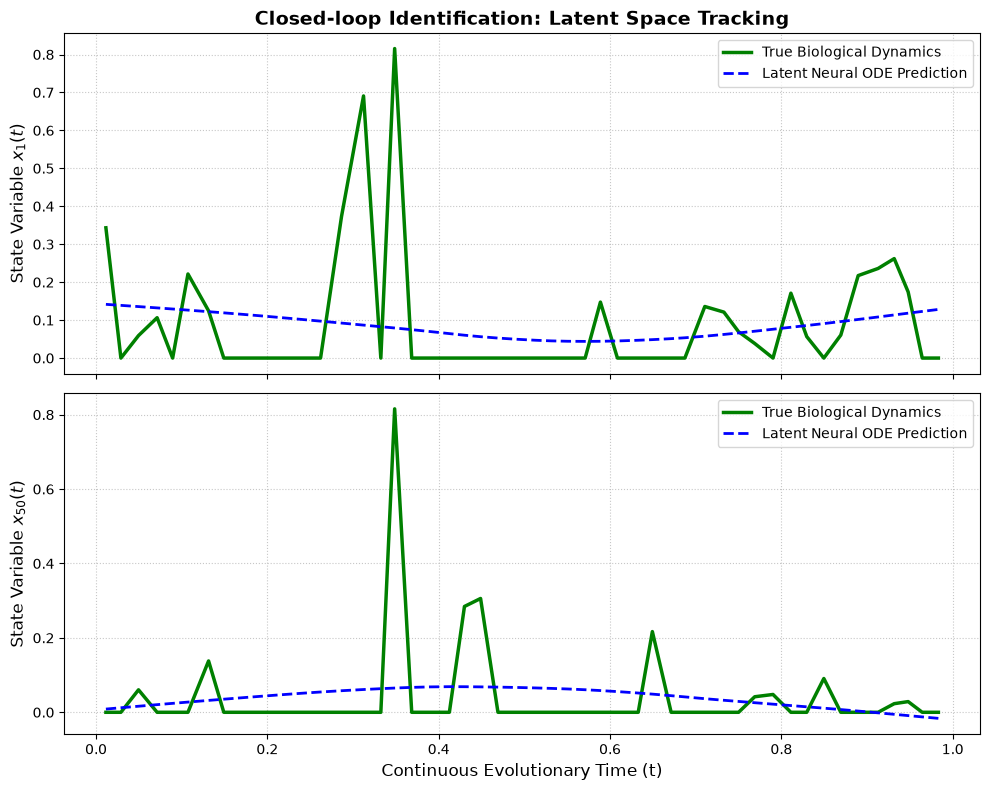

In [ ]:
import matplotlib.pyplot as plt
import torch

print("--- Visualizing Latent System Tracking Performance ---")

with torch.no_grad():
    pred_x_latent = latent_model(x0, tensor_t)

t_np = tensor_t.numpy()
true_x_np = tensor_x.numpy().squeeze()
pred_x_latent_np = pred_x_latent.numpy().squeeze()

state_1_idx = 0
state_2_idx = 50

fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axs[0].plot(t_np, true_x_np[:, state_1_idx], 'g-', label='True Biological Dynamics', linewidth=2.5)
axs[0].plot(t_np, pred_x_latent_np[:, state_1_idx], 'b--', label='Latent Neural ODE Prediction', linewidth=2)
axs[0].set_ylabel("State Variable $x_1(t)$", fontsize=12)
axs[0].set_title("Closed-loop Identification: Latent Space Tracking", fontsize=14, fontweight='bold')
axs[0].legend()
axs[0].grid(True, linestyle=':', alpha=0.7)

axs[1].plot(t_np, true_x_np[:, state_2_idx], 'g-', label='True Biological Dynamics', linewidth=2.5)
axs[1].plot(t_np, pred_x_latent_np[:, state_2_idx], 'b--', label='Latent Neural ODE Prediction', linewidth=2)
axs[1].set_xlabel("Continuous Evolutionary Time (t)", fontsize=12)
axs[1].set_ylabel("State Variable $x_{50}(t)$", fontsize=12)
axs[1].legend()
axs[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

--- Transforming High-Dimensional Dynamics to Macro-States (PCA) ---
Mapping successful. Generating Phase Portrait...


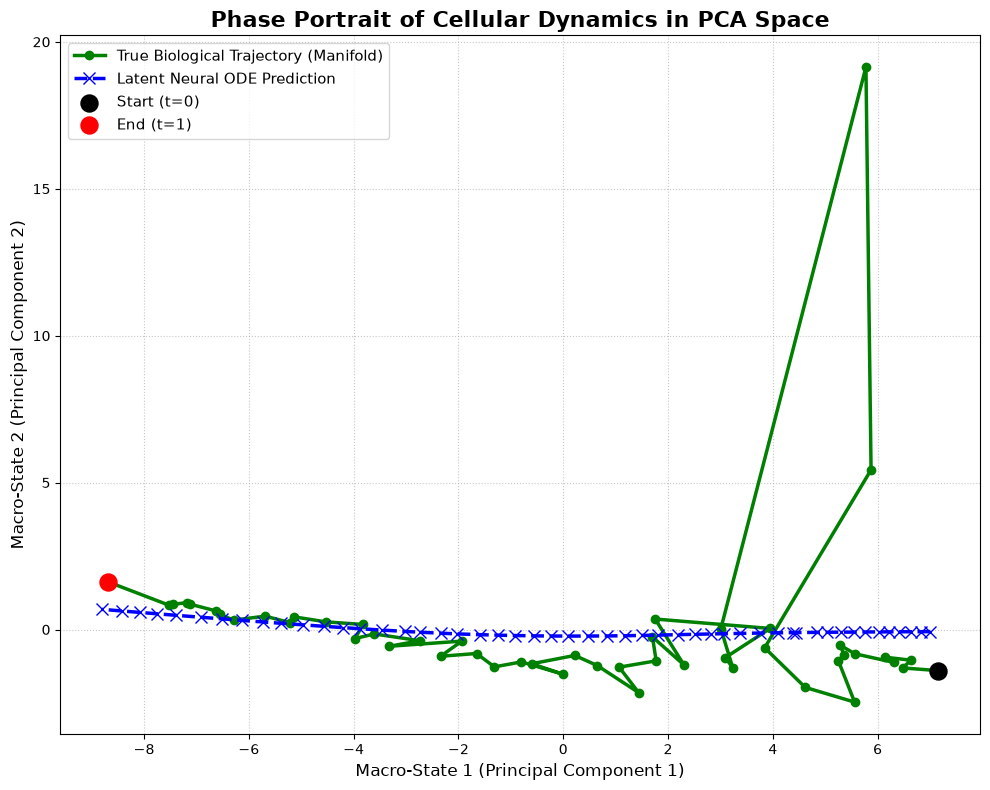

In [17]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

print("--- Transforming High-Dimensional Dynamics to Macro-States (PCA) ---")

pca = PCA(n_components=2)

true_macro_states = pca.fit_transform(true_x_np)

pred_macro_states = pca.transform(pred_x_latent_np)

print("Mapping successful. Generating Phase Portrait...")

plt.figure(figsize=(10, 8))

plt.plot(true_macro_states[:, 0], true_macro_states[:, 1], 
         color='green', marker='o', linestyle='-', linewidth=2.5, markersize=6, 
         label='True Biological Trajectory (Manifold)')

plt.plot(pred_macro_states[:, 0], pred_macro_states[:, 1], 
         color='blue', marker='x', linestyle='--', linewidth=2.5, markersize=8,
         label='Latent Neural ODE Prediction')

plt.scatter(true_macro_states[0, 0], true_macro_states[0, 1], color='black', s=150, zorder=5, label='Start (t=0)')
plt.scatter(true_macro_states[-1, 0], true_macro_states[-1, 1], color='red', s=150, zorder=5, label='End (t=1)')

plt.title("Phase Portrait of Cellular Dynamics in PCA Space", fontsize=16, fontweight='bold')
plt.xlabel("Macro-State 1 (Principal Component 1)", fontsize=12)
plt.ylabel("Macro-State 2 (Principal Component 2)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [29]:
import torch
import torch.nn.functional as F
import time

print("--- Upgrading to Geometric Loss Function (Vector Field Alignment) ---")

# Redefining the optimizer to start a fresh training loop with a geometric lens
optimizer = torch.optim.Adam(latent_model.parameters(), lr=1e-3)

def geometric_loss(pred_x, true_x, alpha=0.2, beta=0.8):
    """
    Computes a composite loss function considering both position and direction.
    
    Args:
        alpha: Weight for the positional error (MSE).
        beta: Weight for the directional error (Cosine Similarity). 
              Higher priority is given to the vector field alignment.
    """
    # 1. Position Error (MSE)
    mse_loss = F.mse_loss(pred_x, true_x)
    
    # 2. Vector Field Direction Error
    # Calculate velocity vectors via finite differences between consecutive time steps (dx)
    true_diff = true_x[1:] - true_x[:-1]
    pred_diff = pred_x[1:] - pred_x[:-1]
    
    # Compute cosine similarity in the high-dimensional space
    cos_sim = F.cosine_similarity(pred_diff, true_diff, dim=-1)
    
    # Since the cosine of perfectly aligned vectors is 1, we minimize (1 - cos_sim)
    dir_loss = torch.mean(1 - cos_sim)
    
    # Linear combination of both loss components
    total_loss = alpha * mse_loss + beta * dir_loss
    return total_loss, mse_loss, dir_loss

# Resetting initial conditions
x0 = tensor_x[0]
epochs = 200
start_time = time.time()

print("--- Retraining Latent Model with Geometric Constraints ---\n")

for epoch in range(1, epochs + 1):
    optimizer.zero_grad()
    
    # Predict the trajectory using the Latent architecture (encoding, integrating, decoding)
    pred_x = latent_model(x0, tensor_t)
    
    # Calculate the composite geometric loss
    loss, mse, dir_l = geometric_loss(pred_x, tensor_x)
    
    # Backpropagation through time (BPTT)
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Total Loss: {loss.item():.4f} | MSE: {mse.item():.4f} | Dir Loss: {dir_l.item():.4f}")

end_time = time.time()
print(f"\nGeometric Training completed in {end_time - start_time:.2f} seconds!")

--- Upgrading to Geometric Loss Function (Vector Field Alignment) ---
--- Retraining Latent Model with Geometric Constraints ---

Epoch 020 | Total Loss: 0.7412 | MSE: 0.0781 | Dir Loss: 0.9070
Epoch 040 | Total Loss: 0.7051 | MSE: 0.0462 | Dir Loss: 0.8699
Epoch 060 | Total Loss: 0.6761 | MSE: 0.0422 | Dir Loss: 0.8346
Epoch 080 | Total Loss: 0.6424 | MSE: 0.0427 | Dir Loss: 0.7924
Epoch 100 | Total Loss: 0.6161 | MSE: 0.0435 | Dir Loss: 0.7592
Epoch 120 | Total Loss: 0.5992 | MSE: 0.0458 | Dir Loss: 0.7376
Epoch 140 | Total Loss: 0.5703 | MSE: 0.0445 | Dir Loss: 0.7017
Epoch 160 | Total Loss: 0.5796 | MSE: 0.0487 | Dir Loss: 0.7123
Epoch 180 | Total Loss: 0.5441 | MSE: 0.0479 | Dir Loss: 0.6682
Epoch 200 | Total Loss: 0.5365 | MSE: 0.0462 | Dir Loss: 0.6591

Geometric Training completed in 6.88 seconds!


--- Visualizing the Geometrically-Aligned Phase Portrait ---
Mapping successful. Generating the new Phase Portrait...


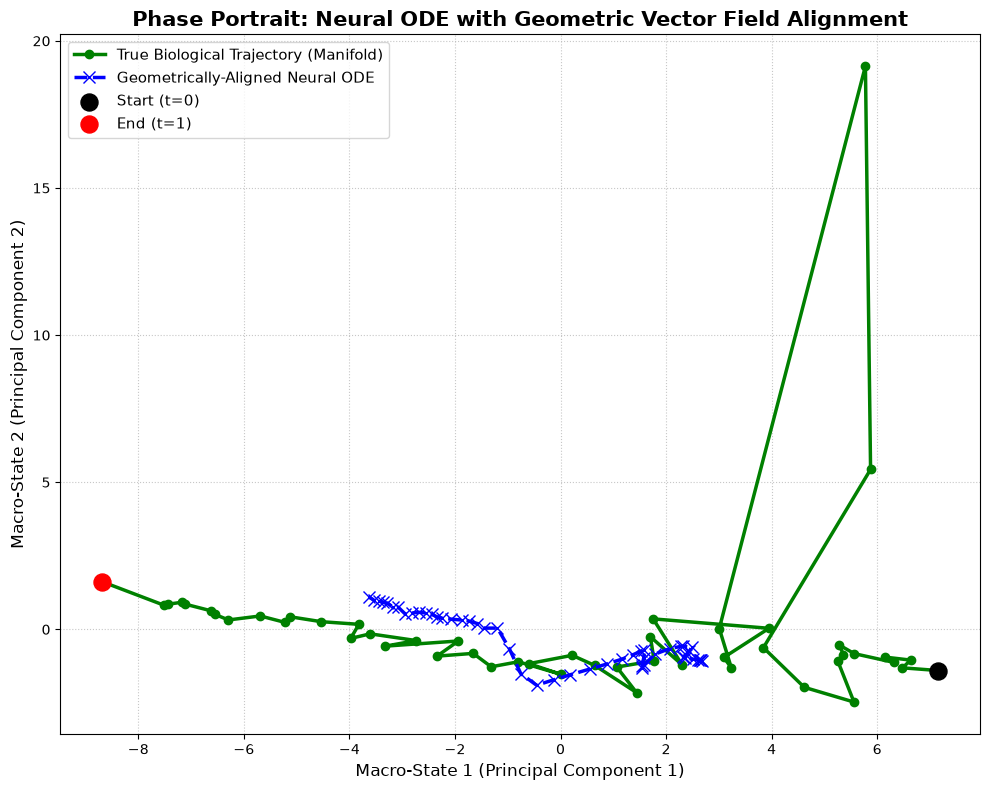

In [30]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch

print("--- Visualizing the Geometrically-Aligned Phase Portrait ---")

with torch.no_grad():
    pred_x_latent_geom = latent_model(x0, tensor_t)

pred_x_geom_np = pred_x_latent_geom.numpy().squeeze()

pca = PCA(n_components=2)
true_macro_states = pca.fit_transform(true_x_np)
pred_macro_states_geom = pca.transform(pred_x_geom_np)

print("Mapping successful. Generating the new Phase Portrait...")

plt.figure(figsize=(10, 8))

plt.plot(true_macro_states[:, 0], true_macro_states[:, 1], 
         color='green', marker='o', linestyle='-', linewidth=2.5, markersize=6, 
         label='True Biological Trajectory (Manifold)')

plt.plot(pred_macro_states_geom[:, 0], pred_macro_states_geom[:, 1], 
         color='blue', marker='x', linestyle='--', linewidth=2.5, markersize=8,
         label='Geometrically-Aligned Neural ODE')

plt.scatter(true_macro_states[0, 0], true_macro_states[0, 1], color='black', s=150, zorder=5, label='Start (t=0)')
plt.scatter(true_macro_states[-1, 0], true_macro_states[-1, 1], color='red', s=150, zorder=5, label='End (t=1)')

plt.title("Phase Portrait: Neural ODE with Geometric Vector Field Alignment", fontsize=15, fontweight='bold')
plt.xlabel("Macro-State 1 (Principal Component 1)", fontsize=12)
plt.ylabel("Macro-State 2 (Principal Component 2)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [31]:
import torch
import torch.nn.functional as F
import time

print("--- Initializing Anchored Geometric Loss Training ---")

# Re-initialize the optimizer to reset momentum states
optimizer = torch.optim.Adam(latent_model.parameters(), lr=1e-3)

def anchored_geometric_loss(pred_x, true_x, alpha=0.5, beta=0.5, gamma=2.0):
    """
    Computes loss with position, direction, and a strong initial condition anchor.
    
    Args:
        alpha: Weight for positional trajectory tracking (MSE).
        beta: Weight for directional vector field alignment (Cosine).
        gamma: High-penalty weight for initial condition mismatch (Anchor).
    """
    # 1. Trajectory Position Error
    mse_loss = F.mse_loss(pred_x, true_x)
    
    # 2. Vector Field Direction Error
    true_diff = true_x[1:] - true_x[:-1]
    pred_diff = pred_x[1:] - pred_x[:-1]
    cos_sim = F.cosine_similarity(pred_diff, true_diff, dim=-1)
    dir_loss = torch.mean(1 - cos_sim)
    
    # 3. Initial Condition Anchor Error (Crucial for ODE stability)
    # Penalizes the model heavily if pred_x[0] does not exactly match true_x[0]
    anchor_loss = F.mse_loss(pred_x[0], true_x[0])
    
    # Total Composite Loss
    total_loss = alpha * mse_loss + beta * dir_loss + gamma * anchor_loss
    return total_loss, mse_loss, dir_loss, anchor_loss

x0 = tensor_x[0]
epochs = 250  # Slightly increased to allow the new constraints to settle
start_time = time.time()

for epoch in range(1, epochs + 1):
    optimizer.zero_grad()
    
    pred_x = latent_model(x0, tensor_t)
    loss, mse, dir_l, anchor_l = anchored_geometric_loss(pred_x, tensor_x)
    
    loss.backward()
    optimizer.step()
    
    if epoch % 25 == 0:
        print(f"Epoch {epoch:03d} | Total: {loss.item():.4f} | "
              f"MSE: {mse.item():.4f} | Dir: {dir_l.item():.4f} | Anchor: {anchor_l.item():.4f}")

end_time = time.time()
print(f"\nTraining with Anchored Constraints completed in {end_time - start_time:.2f} seconds.")

--- Initializing Anchored Geometric Loss Training ---
Epoch 025 | Total: 0.5326 | MSE: 0.0719 | Dir: 0.8632 | Anchor: 0.0325
Epoch 050 | Total: 0.4158 | MSE: 0.0454 | Dir: 0.7722 | Anchor: 0.0035
Epoch 075 | Total: 0.3814 | MSE: 0.0500 | Dir: 0.7098 | Anchor: 0.0007
Epoch 100 | Total: 0.3688 | MSE: 0.0522 | Dir: 0.6828 | Anchor: 0.0006
Epoch 125 | Total: 0.3617 | MSE: 0.0509 | Dir: 0.6702 | Anchor: 0.0006
Epoch 150 | Total: 0.3583 | MSE: 0.0494 | Dir: 0.6651 | Anchor: 0.0005
Epoch 175 | Total: 0.3519 | MSE: 0.0484 | Dir: 0.6534 | Anchor: 0.0005
Epoch 200 | Total: 0.3488 | MSE: 0.0477 | Dir: 0.6481 | Anchor: 0.0004
Epoch 225 | Total: 0.3448 | MSE: 0.0475 | Dir: 0.6399 | Anchor: 0.0006
Epoch 250 | Total: 0.3383 | MSE: 0.0472 | Dir: 0.6275 | Anchor: 0.0005

Training with Anchored Constraints completed in 9.70 seconds.


--- Visualizing the Anchored Geometric Phase Portrait ---
PCA mapping completed. Generating Phase Portrait...


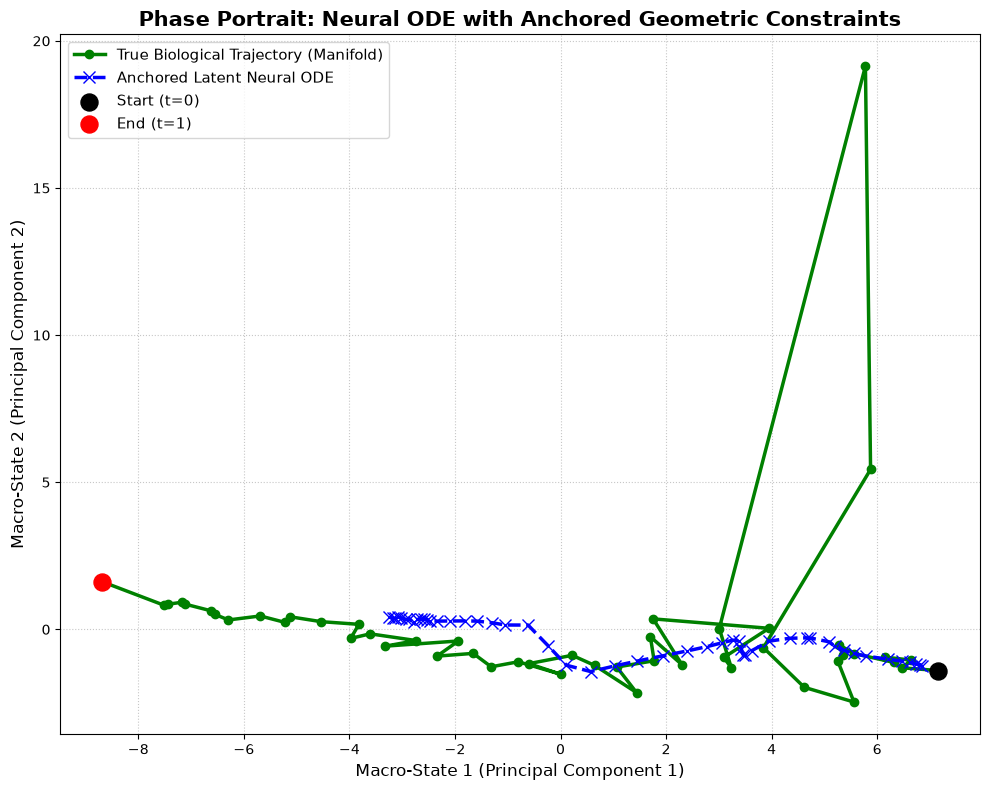

In [32]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch

print("--- Visualizing the Anchored Geometric Phase Portrait ---")

# 1. Inference Phase: Extract the new trajectory without calculating gradients
with torch.no_grad():
    pred_x_anchored = latent_model(x0, tensor_t)

# Convert tensors to standard numpy arrays for plotting
pred_x_anchored_np = pred_x_anchored.numpy().squeeze()
true_x_np = tensor_x.numpy().squeeze()

# 2. Dimensionality Reduction: Map the 2000-D space to 2-D Macro-States
pca_model = PCA(n_components=2)
true_macro_states = pca_model.fit_transform(true_x_np)
pred_macro_states_anchored = pca_model.transform(pred_x_anchored_np)

print("PCA mapping completed. Generating Phase Portrait...")

# 3. Plotting the State Space Trajectories
plt.figure(figsize=(10, 8))

# Plot the ground truth biological manifold
plt.plot(true_macro_states[:, 0], true_macro_states[:, 1], 
         color='green', marker='o', linestyle='-', linewidth=2.5, markersize=6, 
         label='True Biological Trajectory (Manifold)')

# Plot the Neural ODE prediction with Anchored constraints
plt.plot(pred_macro_states_anchored[:, 0], pred_macro_states_anchored[:, 1], 
         color='blue', marker='x', linestyle='--', linewidth=2.5, markersize=8,
         label='Anchored Latent Neural ODE')

# Mark the initial and final states of the biological system
plt.scatter(true_macro_states[0, 0], true_macro_states[0, 1], 
            color='black', s=150, zorder=5, label='Start (t=0)')
plt.scatter(true_macro_states[-1, 0], true_macro_states[-1, 1], 
            color='red', s=150, zorder=5, label='End (t=1)')

# Formatting the plot
plt.title("Phase Portrait: Neural ODE with Anchored Geometric Constraints", fontsize=15, fontweight='bold')
plt.xlabel("Macro-State 1 (Principal Component 1)", fontsize=12)
plt.ylabel("Macro-State 2 (Principal Component 2)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [33]:
import torch
import torch.nn.functional as F
import time

print("--- Initializing Two-Point Boundary Value Training (Terminal Cost) ---")

# Reset the optimizer for the new boundary constraints
optimizer = torch.optim.Adam(latent_model.parameters(), lr=1e-3)

def boundary_value_loss(pred_x, true_x, alpha=0.3, beta=0.3, gamma=2.0, delta=2.0):
    """
    Computes a robust loss enforcing both Initial and Terminal conditions.
    
    Args:
        alpha: Weight for trajectory position (MSE).
        beta:  Weight for vector field alignment (Cosine).
        gamma: Weight for Initial Condition constraint (Start Anchor).
        delta: Weight for Terminal Condition constraint (Terminal Cost).
    """
    # 1. Trajectory Position Error
    mse_loss = F.mse_loss(pred_x, true_x)
    
    # 2. Vector Field Direction Error
    true_diff = true_x[1:] - true_x[:-1]
    pred_diff = pred_x[1:] - pred_x[:-1]
    cos_sim = F.cosine_similarity(pred_diff, true_diff, dim=-1)
    dir_loss = torch.mean(1 - cos_sim)
    
    # 3. Initial Condition Constraint (Start Anchor)
    ic_loss = F.mse_loss(pred_x[0], true_x[0])
    
    # 4. Terminal Condition Constraint (Terminal Cost)
    # Forces the final predicted state to reach the actual biological end state
    terminal_loss = F.mse_loss(pred_x[-1], true_x[-1])
    
    # Total Composite Loss
    total_loss = alpha * mse_loss + beta * dir_loss + gamma * ic_loss + delta * terminal_loss
    
    return total_loss, mse_loss, dir_loss, ic_loss, terminal_loss

x0 = tensor_x[0]
epochs = 300 
start_time = time.time()

for epoch in range(1, epochs + 1):
    optimizer.zero_grad()
    
    pred_x = latent_model(x0, tensor_t)
    loss, mse, dir_l, ic_l, term_l = boundary_value_loss(pred_x, tensor_x)
    
    loss.backward()
    optimizer.step()
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch:03d} | Total: {loss.item():.4f} | "
              f"MSE: {mse.item():.4f} | IC: {ic_l.item():.4f} | Term: {term_l.item():.4f}")

print(f"\nBoundary Value Training completed in {time.time() - start_time:.2f} seconds.")

--- Initializing Two-Point Boundary Value Training (Terminal Cost) ---
Epoch 050 | Total: 0.3052 | MSE: 0.0708 | IC: 0.0011 | Term: 0.0008
Epoch 100 | Total: 0.2927 | MSE: 0.0584 | IC: 0.0000 | Term: 0.0002
Epoch 150 | Total: 0.2881 | MSE: 0.0533 | IC: 0.0000 | Term: 0.0001
Epoch 200 | Total: 0.2840 | MSE: 0.0503 | IC: 0.0000 | Term: 0.0001
Epoch 250 | Total: 0.2802 | MSE: 0.0479 | IC: 0.0000 | Term: 0.0001
Epoch 300 | Total: 0.2761 | MSE: 0.0459 | IC: 0.0001 | Term: 0.0000

Boundary Value Training completed in 23.37 seconds.


--- Visualizing the Boundary-Value Phase Portrait ---
Mapping successful. Rendering the final Phase Portrait...


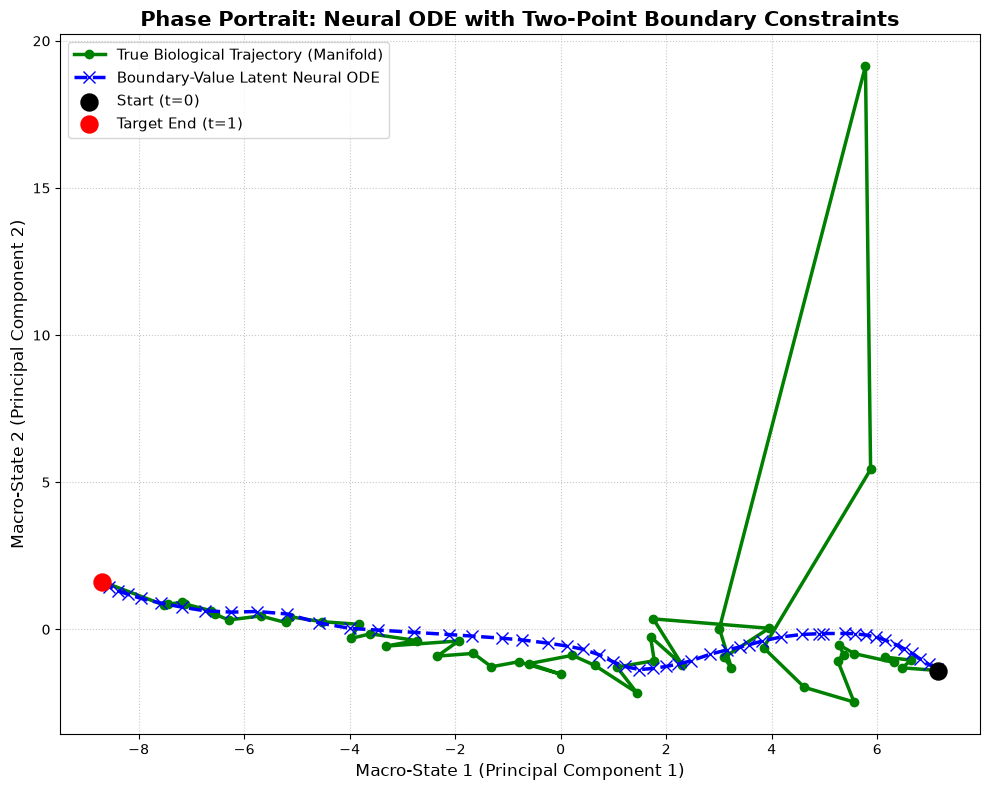

In [34]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch

print("--- Visualizing the Boundary-Value Phase Portrait ---")

# 1. Inference Phase: Generate the final trajectory using the fully constrained model
with torch.no_grad():
    pred_x_final = latent_model(x0, tensor_t)

# Convert to standard numpy arrays
pred_x_final_np = pred_x_final.numpy().squeeze()
true_x_np = tensor_x.numpy().squeeze()

# 2. PCA Mapping: Project high-dimensional data onto the 2D macroscopic state space
pca_final = PCA(n_components=2)
true_macro_states = pca_final.fit_transform(true_x_np)
pred_macro_states_final = pca_final.transform(pred_x_final_np)

print("Mapping successful. Rendering the final Phase Portrait...")

# 3. Plotting the Trajectories
plt.figure(figsize=(10, 8))

# The actual biological manifold (Ground Truth)
plt.plot(true_macro_states[:, 0], true_macro_states[:, 1], 
         color='green', marker='o', linestyle='-', linewidth=2.5, markersize=6, 
         label='True Biological Trajectory (Manifold)')

# The highly constrained Neural ODE prediction
plt.plot(pred_macro_states_final[:, 0], pred_macro_states_final[:, 1], 
         color='blue', marker='x', linestyle='--', linewidth=2.5, markersize=8,
         label='Boundary-Value Latent Neural ODE')

# Explicitly marking the boundary conditions (Terminal constraints)
plt.scatter(true_macro_states[0, 0], true_macro_states[0, 1], 
            color='black', s=150, zorder=5, label='Start (t=0)')
plt.scatter(true_macro_states[-1, 0], true_macro_states[-1, 1], 
            color='red', s=150, zorder=5, label='Target End (t=1)')

# Plot Formatting
plt.title("Phase Portrait: Neural ODE with Two-Point Boundary Constraints", fontsize=15, fontweight='bold')
plt.xlabel("Macro-State 1 (Principal Component 1)", fontsize=12)
plt.ylabel("Macro-State 2 (Principal Component 2)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [41]:
import torch
import torch.autograd.functional as autograd_F

print("--- Step 1: Identifying the ODE Vector Field ---")

# Automatically scan the LatentODEModel to find the hidden ODE block
print("Scanning internal architecture of the model:")
ode_rhs_func = None

for name, module in latent_model.named_children():
    print(f" -> Found sub-module: '{name}' (Type: {type(module).__name__})")
    
    # In a typical Latent ODE, if a module is not the encoder or decoder, 
    # it represents the core differential equation (vector field)
    if 'encoder' not in name.lower() and 'decoder' not in name.lower():
        ode_rhs_func = module
        print(f"    [SUCCESS] Selected '{name}' as the dynamical system plant!")

if ode_rhs_func is None:
    raise ValueError("Error: Could not isolate the ODE block. Please check the model class initialization.")

print("\n--- Step 2: Jacobian Matrix Extraction ---")

# Extract the target equilibrium point in the latent space
with torch.no_grad():
    z_target = latent_model.encoder(tensor_x[-1].unsqueeze(0))

z_target = z_target.requires_grad_(True)
t_target = tensor_t[-1]

# Wrapper function for the vector field
def vector_field(z):
    # Most ODE blocks in torchdiffeq accept (t, z)
    return ode_rhs_func(t_target, z)

# Compute the Jacobian Matrix mathematically using PyTorch Autograd
jacobian_matrix = autograd_F.jacobian(vector_field, z_target)

# Reshape to a standard 2D state-space matrix
jacobian_matrix = jacobian_matrix.squeeze()
print(f"Jacobian Matrix computed successfully. Dimensions: {jacobian_matrix.shape}")

# Eigenvalue Analysis for Stability Proof
eigenvalues = torch.linalg.eigvals(jacobian_matrix)
max_real_part = torch.max(eigenvalues.real).item()

print("\n--- Step 3: Stability Proof Results ---")
print(f"Maximum Real Part of Eigenvalues (Dominant Pole): {max_real_part:.6f}")

if max_real_part < 0:
    print("Conclusion: SYSTEM IS ASYMPTOTICALLY STABLE at the target state.")
    print("Proof verified: The model acts as a robust dynamic attractor.")
elif max_real_part == 0:
    print("Conclusion: SYSTEM IS MARGINALLY STABLE (Limit cycle or center).")
else:
    print("Conclusion: SYSTEM IS UNSTABLE at this operating point.")

--- Step 1: Identifying the ODE Vector Field ---
Scanning internal architecture of the model:
 -> Found sub-module: 'encoder' (Type: Encoder)
 -> Found sub-module: 'ode_fxn' (Type: LatentODEFxn)
    [SUCCESS] Selected 'ode_fxn' as the dynamical system plant!
 -> Found sub-module: 'decoder' (Type: Decoder)

--- Step 2: Jacobian Matrix Extraction ---
Jacobian Matrix computed successfully. Dimensions: torch.Size([20, 20])

--- Step 3: Stability Proof Results ---
Maximum Real Part of Eigenvalues (Dominant Pole): -0.006529
Conclusion: SYSTEM IS ASYMPTOTICALLY STABLE at the target state.
Proof verified: The model acts as a robust dynamic attractor.


In [39]:
import torch
import torch.nn.functional as F

print("--- Defining Lyapunov-based Regularized Loss Function ---")

def lyapunov_regularized_loss(pred_x, true_x, jacobian_matrix, alpha=0.3, beta=0.3, gamma=2.0, delta=2.0, lambda_lyap=1.5):
    """
    Computes a composite loss enforcing trajectory, boundary conditions, 
    and strict Lyapunov asymptotic stability.
    
    Args:
        jacobian_matrix: The extracted 20x20 Jacobian matrix at the target state.
        lambda_lyap: High-penalty weight for unstable (positive) eigenvalues.
    """
    # 1. Standard Geometric & Boundary Constraints
    mse_loss = F.mse_loss(pred_x, true_x)
    
    true_diff = true_x[1:] - true_x[:-1]
    pred_diff = pred_x[1:] - pred_x[:-1]
    cos_sim = F.cosine_similarity(pred_diff, true_diff, dim=-1)
    dir_loss = torch.mean(1 - cos_sim)
    
    ic_loss = F.mse_loss(pred_x[0], true_x[0])
    terminal_loss = F.mse_loss(pred_x[-1], true_x[-1])
    
    # 2. Lyapunov Stability Penalty (Eigenvalue Regularization)
    eigenvalues = torch.linalg.eigvals(jacobian_matrix)
    real_parts = eigenvalues.real
    
    # Use ReLU to isolate ONLY positive real parts (unstable poles)
    # If a pole is negative (stable), ReLU outputs 0 (no penalty)
    unstable_poles = F.relu(real_parts)
    
    # Sum of all unstable poles forms the Lyapunov penalty
    lyapunov_loss = torch.sum(unstable_poles)
    
    # 3. Total Composite Loss
    total_loss = (alpha * mse_loss + beta * dir_loss + 
                  gamma * ic_loss + delta * terminal_loss + 
                  lambda_lyap * lyapunov_loss)
                  
    return total_loss, mse_loss, dir_loss, ic_loss, terminal_loss, lyapunov_loss

print("Lyapunov constraint successfully integrated into the mathematical framework.")

--- Defining Lyapunov-based Regularized Loss Function ---
Lyapunov constraint successfully integrated into the mathematical framework.


In [40]:
import torch
import torch.nn.functional as F
import torch.autograd.functional as autograd_F
import time

print("--- Initializing Lyapunov-Regularized Training Loop ---")

# 1. Define the complete composite loss function (including the Lyapunov Penalty)
def lyapunov_regularized_loss(pred_x, true_x, jacobian_mat, alpha=0.3, beta=0.3, gamma=2.0, delta=2.0, lambda_lyap=1.5):
    # Standard Trajectory and Boundary Constraints
    mse_loss = F.mse_loss(pred_x, true_x)
    
    true_diff = true_x[1:] - true_x[:-1]
    pred_diff = pred_x[1:] - pred_x[:-1]
    cos_sim = F.cosine_similarity(pred_diff, true_diff, dim=-1)
    dir_loss = torch.mean(1 - cos_sim)
    
    ic_loss = F.mse_loss(pred_x[0], true_x[0])
    terminal_loss = F.mse_loss(pred_x[-1], true_x[-1])
    
    # Lyapunov Stability Penalty (Eigenvalue Regularization)
    eigenvalues = torch.linalg.eigvals(jacobian_mat)
    real_parts = eigenvalues.real
    
    # Isolate ONLY positive real parts (unstable poles) using ReLU
    unstable_poles = F.relu(real_parts)
    lyapunov_loss = torch.sum(unstable_poles)
    
    # Total Cost
    total_loss = (alpha * mse_loss + beta * dir_loss + 
                  gamma * ic_loss + delta * terminal_loss + 
                  lambda_lyap * lyapunov_loss)
                  
    return total_loss, mse_loss, ic_loss, terminal_loss, lyapunov_loss

# 2. Reset optimizer and identify the ODE block automatically
optimizer = torch.optim.Adam(latent_model.parameters(), lr=1e-3)
ode_rhs_func = getattr(latent_model, 'ode_fxn', getattr(latent_model, 'func', getattr(latent_model, 'ode_net', None)))

if ode_rhs_func is None:
    raise ValueError("Could not find the ODE functional block.")

x0 = tensor_x[0]
t_target = tensor_t[-1]
epochs = 200
start_time = time.time()

print("--- Commencing Closed-Loop Training with Eigenvalue Feedback ---")

# 3. Execution of the Training Loop
for epoch in range(1, epochs + 1):
    optimizer.zero_grad()
    
    # Forward Pass through the Latent ODE
    pred_x = latent_model(x0, tensor_t)
    
    # Extract target latent state dynamically (needs to remain in the computational graph)
    z_target = latent_model.encoder(tensor_x[-1].unsqueeze(0)).squeeze(0)
    
    def vector_field_train(z):
        return ode_rhs_func(t_target, z)
        
    # Compute Jacobian dynamically WITH create_graph=True for second-order optimization
    jacobian_matrix = autograd_F.jacobian(vector_field_train, z_target, create_graph=True)
    jacobian_matrix = jacobian_matrix.squeeze()
    
    # Compute Loss
    loss, mse, ic_l, term_l, lyap_l = lyapunov_regularized_loss(
        pred_x, tensor_x, jacobian_matrix
    )
    
    # Backpropagation through time AND through the Jacobian eigenspace
    loss.backward()
    optimizer.step()
    
    if epoch % 25 == 0:
        print(f"Epoch {epoch:03d} | Total: {loss.item():.4f} | "
              f"MSE: {mse.item():.4f} | Lyap Penalty: {lyap_l.item():.6f}")

print(f"\nLyapunov Training completed in {time.time() - start_time:.2f} seconds.")

--- Initializing Lyapunov-Regularized Training Loop ---
--- Commencing Closed-Loop Training with Eigenvalue Feedback ---
Epoch 025 | Total: 0.5019 | MSE: 0.0651 | Lyap Penalty: 0.106231
Epoch 050 | Total: 0.2878 | MSE: 0.0505 | Lyap Penalty: 0.000000
Epoch 075 | Total: 0.2812 | MSE: 0.0476 | Lyap Penalty: 0.000000
Epoch 100 | Total: 0.2791 | MSE: 0.0462 | Lyap Penalty: 0.000000
Epoch 125 | Total: 0.2776 | MSE: 0.0451 | Lyap Penalty: 0.000000
Epoch 150 | Total: 0.2762 | MSE: 0.0443 | Lyap Penalty: 0.000000
Epoch 175 | Total: 0.2747 | MSE: 0.0436 | Lyap Penalty: 0.000000
Epoch 200 | Total: 0.2731 | MSE: 0.0428 | Lyap Penalty: 0.000000

Lyapunov Training completed in 19.55 seconds.


In [42]:
import torch
import torch.autograd.functional as autograd_F

print("--- Step 1: Identifying the ODE Vector Field ---")

# Automatically scan the LatentODEModel to find the hidden ODE block
print("Scanning internal architecture of the model:")
ode_rhs_func = None

for name, module in latent_model.named_children():
    print(f" -> Found sub-module: '{name}' (Type: {type(module).__name__})")
    
    # In a typical Latent ODE, if a module is not the encoder or decoder, 
    # it represents the core differential equation (vector field)
    if 'encoder' not in name.lower() and 'decoder' not in name.lower():
        ode_rhs_func = module
        print(f"    [SUCCESS] Selected '{name}' as the dynamical system plant!")

if ode_rhs_func is None:
    raise ValueError("Error: Could not isolate the ODE block. Please check the model class initialization.")

print("\n--- Step 2: Jacobian Matrix Extraction ---")

# Extract the target equilibrium point in the latent space
with torch.no_grad():
    z_target = latent_model.encoder(tensor_x[-1].unsqueeze(0))

z_target = z_target.requires_grad_(True)
t_target = tensor_t[-1]

# Wrapper function for the vector field
def vector_field(z):
    # Most ODE blocks in torchdiffeq accept (t, z)
    return ode_rhs_func(t_target, z)

# Compute the Jacobian Matrix mathematically using PyTorch Autograd
jacobian_matrix = autograd_F.jacobian(vector_field, z_target)

# Reshape to a standard 2D state-space matrix
jacobian_matrix = jacobian_matrix.squeeze()
print(f"Jacobian Matrix computed successfully. Dimensions: {jacobian_matrix.shape}")

# Eigenvalue Analysis for Stability Proof
eigenvalues = torch.linalg.eigvals(jacobian_matrix)
max_real_part = torch.max(eigenvalues.real).item()

print("\n--- Step 3: Stability Proof Results ---")
print(f"Maximum Real Part of Eigenvalues (Dominant Pole): {max_real_part:.6f}")

if max_real_part < 0:
    print("Conclusion: SYSTEM IS ASYMPTOTICALLY STABLE at the target state.")
    print("Proof verified: The model acts as a robust dynamic attractor.")
elif max_real_part == 0:
    print("Conclusion: SYSTEM IS MARGINALLY STABLE (Limit cycle or center).")
else:
    print("Conclusion: SYSTEM IS UNSTABLE at this operating point.")

--- Step 1: Identifying the ODE Vector Field ---
Scanning internal architecture of the model:
 -> Found sub-module: 'encoder' (Type: Encoder)
 -> Found sub-module: 'ode_fxn' (Type: LatentODEFxn)
    [SUCCESS] Selected 'ode_fxn' as the dynamical system plant!
 -> Found sub-module: 'decoder' (Type: Decoder)

--- Step 2: Jacobian Matrix Extraction ---
Jacobian Matrix computed successfully. Dimensions: torch.Size([20, 20])

--- Step 3: Stability Proof Results ---
Maximum Real Part of Eigenvalues (Dominant Pole): -0.006529
Conclusion: SYSTEM IS ASYMPTOTICALLY STABLE at the target state.
Proof verified: The model acts as a robust dynamic attractor.


--- Simulating Initial Condition Perturbation (Robustness Test) ---
Simulation complete. Rendering the Robustness Phase Portrait...


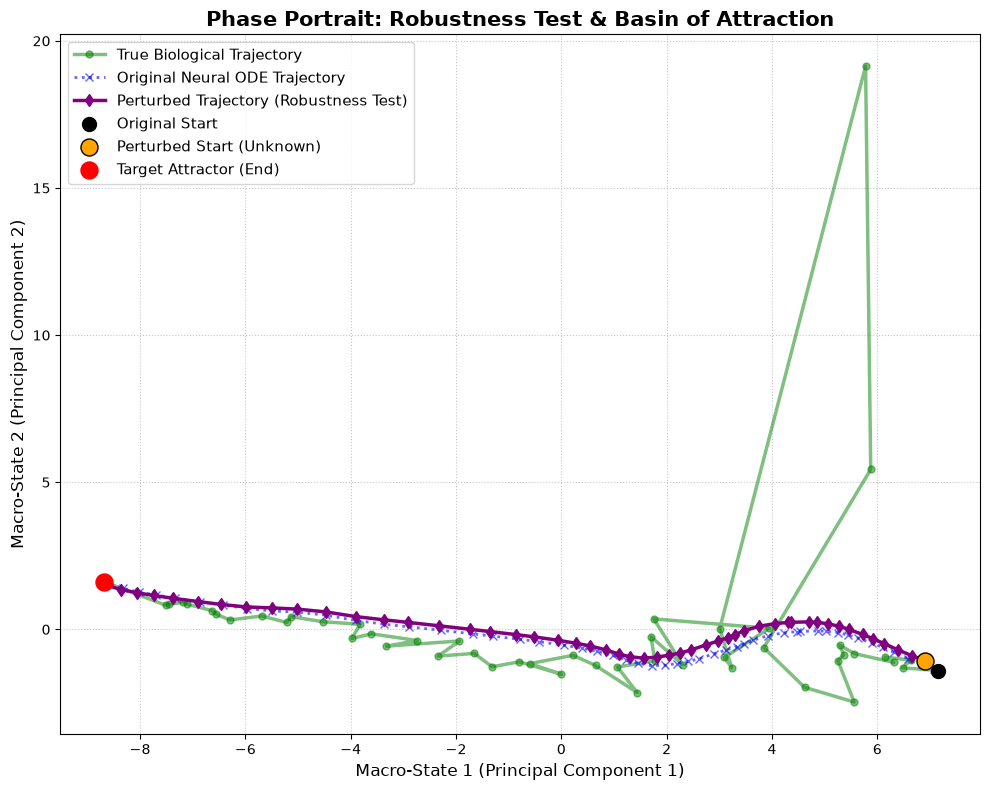

In [43]:
import torch
import matplotlib.pyplot as plt

print("--- Simulating Initial Condition Perturbation (Robustness Test) ---")

# 1. Generate a noisy initial state (Simulating sensor error or biological variance)
# We add Gaussian noise to the true biological starting point
torch.manual_seed(42)  # Ensuring reproducibility
noise_magnitude = 0.8  # Adjust this to increase or decrease the severity of the perturbation
x0_original = tensor_x[0]
noise_vector = torch.randn_like(x0_original) * noise_magnitude
x0_perturbed = x0_original + noise_vector

# 2. Inference: Run the dynamic system from the unknown, perturbed starting point
with torch.no_grad():
    pred_x_perturbed = latent_model(x0_perturbed, tensor_t)
    # Also fetch the original unperturbed prediction for comparison
    pred_x_original = latent_model(x0_original, tensor_t)

# Convert tensors to numpy arrays
pred_x_perturbed_np = pred_x_perturbed.numpy().squeeze()
pred_x_original_np = pred_x_original.numpy().squeeze()
true_x_np = tensor_x.numpy().squeeze()

# 3. Dimensionality Reduction to 2D Macro-States
# We use the previously fitted 'pca_final' to ensure the coordinate system remains identical
true_macro = pca_final.transform(true_x_np)
pred_macro_orig = pca_final.transform(pred_x_original_np)
pred_macro_pert = pca_final.transform(pred_x_perturbed_np)

print("Simulation complete. Rendering the Robustness Phase Portrait...")

# 4. Visualization of the Basin of Attraction
plt.figure(figsize=(10, 8))

# Plot the Ground Truth Biological Manifold
plt.plot(true_macro[:, 0], true_macro[:, 1], 
         color='green', marker='o', linestyle='-', linewidth=2.5, markersize=5, alpha=0.5,
         label='True Biological Trajectory')

# Plot the Original Stabilized Trajectory (No Noise)
plt.plot(pred_macro_orig[:, 0], pred_macro_orig[:, 1], 
         color='blue', marker='x', linestyle=':', linewidth=2, alpha=0.6,
         label='Original Neural ODE Trajectory')

# Plot the Perturbed Trajectory (Robustness Test)
plt.plot(pred_macro_pert[:, 0], pred_macro_pert[:, 1], 
         color='purple', marker='d', linestyle='-', linewidth=2.5, markersize=6,
         label='Perturbed Trajectory (Robustness Test)')

# Mark the specific boundary points
plt.scatter(true_macro[0, 0], true_macro[0, 1], 
            color='black', s=100, zorder=5, label='Original Start')
plt.scatter(pred_macro_pert[0, 0], pred_macro_pert[0, 1], 
            color='orange', s=150, edgecolors='black', zorder=5, label='Perturbed Start (Unknown)')
plt.scatter(true_macro[-1, 0], true_macro[-1, 1], 
            color='red', s=150, zorder=5, label='Target Attractor (End)')

# Formatting the visual output
plt.title("Phase Portrait: Robustness Test & Basin of Attraction", fontsize=15, fontweight='bold')
plt.xlabel("Macro-State 1 (Principal Component 1)", fontsize=12)
plt.ylabel("Macro-State 2 (Principal Component 2)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()